<a href="https://colab.research.google.com/github/muiddd/5thSemester_PCVK/blob/main/Week06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

Mounted at /content/drive


In [3]:
def convolution2d(image, kernel, stride, padding):
    # Dapatkan ukuran gambar dan kernel
    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape

    # Menambahkan padding pada citra input
    if padding > 0:
        padded_image = np.zeros((image_height + 2 * padding, image_width + 2 * padding))
        padded_image[padding:-padding, padding:-padding] = image
    else:
        padded_image = image.copy()

    # Menghitung dimensi output citra hasil konvolusi
    output_height = int(((image_height - kernel_height + 2 * padding) / stride) + 1)
    output_width = int(((image_width - kernel_width + 2 * padding) / stride) + 1)

    output_image = np.zeros((output_height, output_width))

    # Operasi konvolusi (menggeser kernel)
    for y in range(0, output_height):
        for x in range(0, output_width):
            # Posisi y dan x pada citra yang dipadding (mempertimbangkan stride)
            y_start = y * stride
            y_end = y_start + kernel_height
            x_start = x * stride
            x_end = x_start + kernel_width

            # Potong bagian citra (Region of Interest)
            roi = padded_image[y_start:y_end, x_start:x_end]

            # Perkalian elemen matriks dan penjumlahannya
            output_image[y, x] = np.sum(roi * kernel)

    return output_image

In [4]:
# Pastikan path folder sesuai dengan struktur folder di Drive Anda
img = cv.imread('/content/drive/MyDrive/PCVK/Images/mandrill.tiff')

# Mengubah citra menjadi grayscale
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

In [5]:
# image sharpen
kernel_sharpen = np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]])

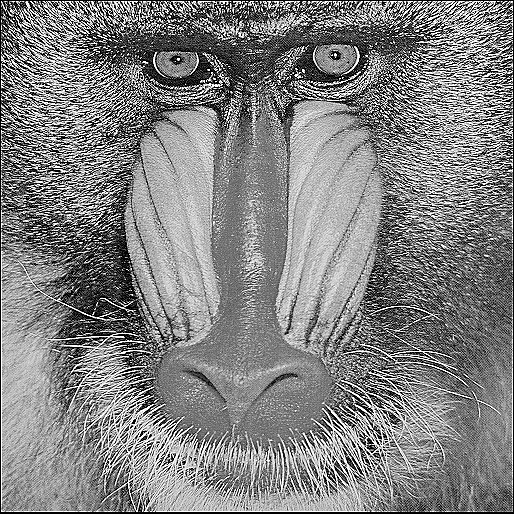

In [6]:
# Memanggil fungsi konvolusi
hasil_sharpen = convolution2d(img_gray, kernel_sharpen, 1, 2)

# Menampilkan hasil gambar
cv2_imshow(hasil_sharpen)


--- Hasil Average Filter ---


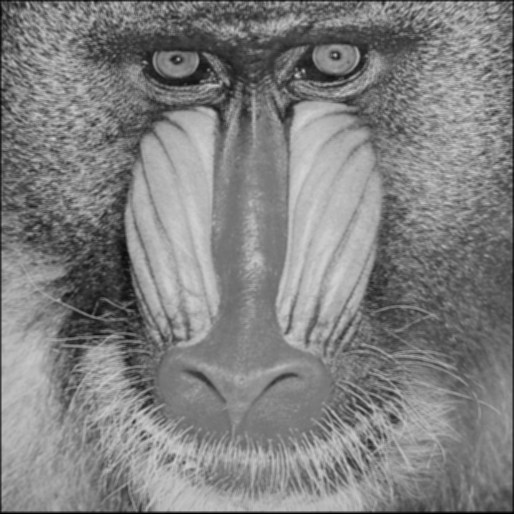


--- Hasil Low Pass Filter ---


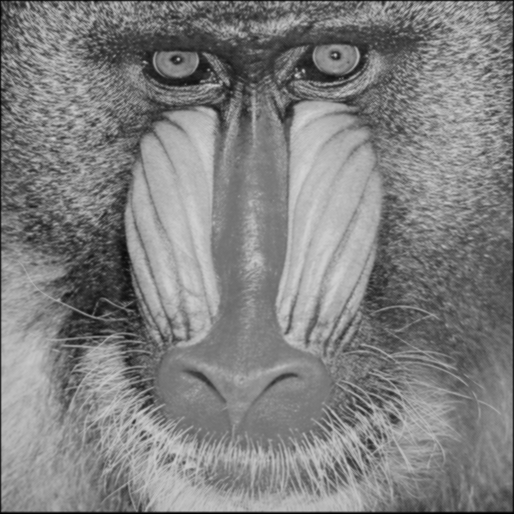


--- Hasil High Pass Filter ---


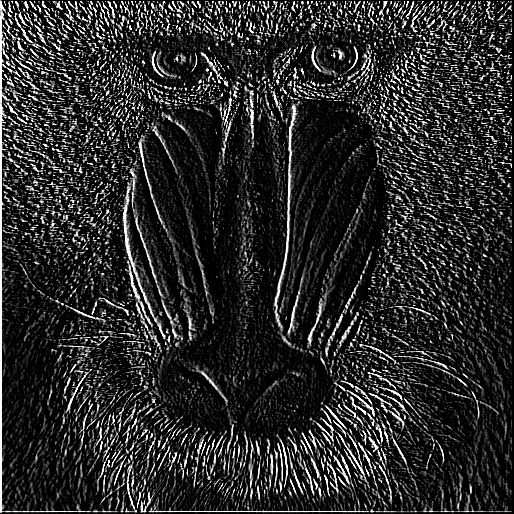


--- Hasil Sharpen ---


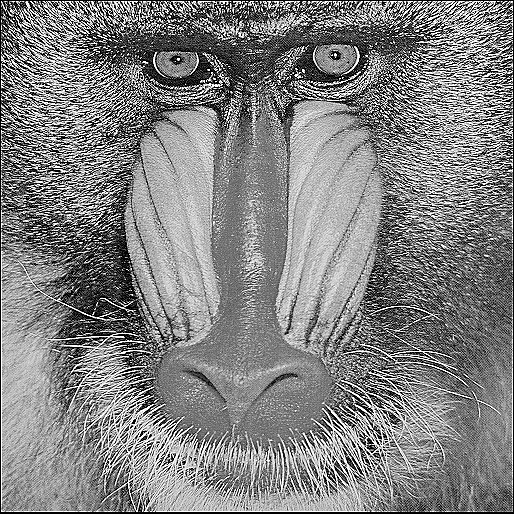


--- Hasil Emboss ---


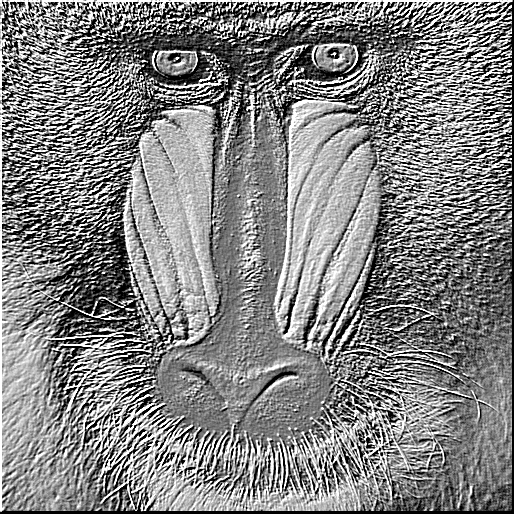


--- Hasil Left Sobel Edge Detection ---


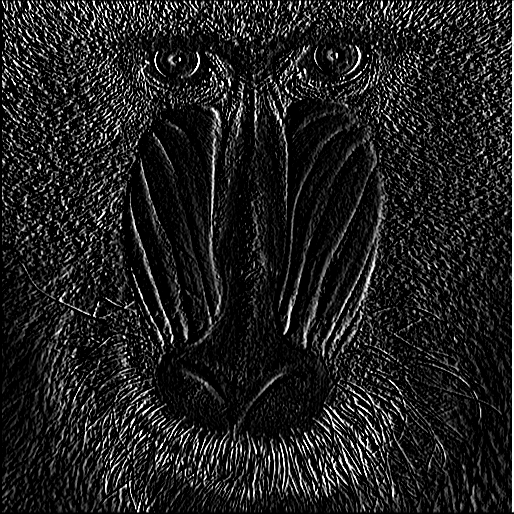


--- Hasil Canny Edge Detection ---


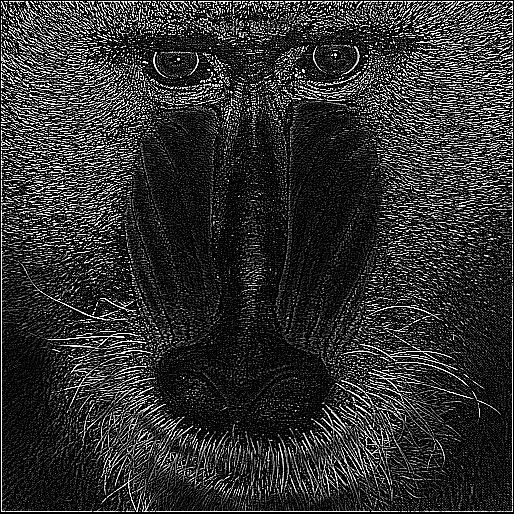


--- Hasil 21x21 Gaussian Blur ---


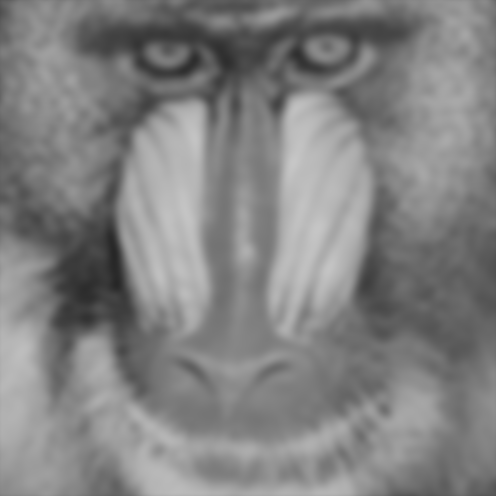

In [7]:
# 1. Average Filter
kernel_average = np.array([[1, 1, 1],
                           [1, 1, 1],
                           [1, 1, 1]]) / 9

# 2. Low Pass Filter
kernel_lpf = np.array([[1, 1, 1],
                       [1, 4, 1],
                       [1, 1, 1]]) / 12

# 3. High Pass Filter
kernel_hpf = np.array([[-1, 0, 1],
                       [-1, 0, 3],
                       [-3, 0, 1]])

# 4. Sharpen
kernel_sharpen = np.array([[ 0, -1,  0],
                           [-1,  5, -1],
                           [ 0, -1,  0]])

# 5. Emboss
kernel_emboss = np.array([[-2, -1,  0],
                          [-1,  1,  1],
                          [ 0,  1,  2]])

# 6. Left Sobel Edge Detection
kernel_left_sobel = np.array([[ 1,  0, -1],
                              [ 2,  0, -2],
                              [ 1,  0, -1]])

# 7. Canny Edge Detection (Laplacian Mask sesuai tabel modul)
kernel_canny = np.array([[-1, -1, -1],
                         [-1,  8, -1],
                         [-1, -1, -1]])

# 8. 21x21 Gaussian Blur
kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_1d = cv.getGaussianKernel(kernel_size, sigma)
# Mengkalikan array 1D untuk mendapatkan kernel 2D
kernel_gaussian = gaussian_1d @ gaussian_1d.transpose()

from google.colab.patches import cv2_imshow

# Kumpulkan semua kernel ke dalam satu dictionary agar mudah diproses
daftar_filter = {
    "Average Filter": kernel_average,
    "Low Pass Filter": kernel_lpf,
    "High Pass Filter": kernel_hpf,
    "Sharpen": kernel_sharpen,
    "Emboss": kernel_emboss,
    "Left Sobel Edge Detection": kernel_left_sobel,
    "Canny Edge Detection": kernel_canny,
    "21x21 Gaussian Blur": kernel_gaussian
}

# Lakukan konvolusi dan tampilkan untuk setiap filter
for nama_filter, kernel in daftar_filter.items():
    print(f"\n--- Hasil {nama_filter} ---")

    # Gunakan stride = 1 dan padding = 2
    # Pastikan variabel 'img_gray' dari langkah 2.d sudah diload sebelumnya
    hasil_konvolusi = convolution2d(img_gray, kernel, 1, 2)

    # Tampilkan gambar
    cv2_imshow(hasil_konvolusi)

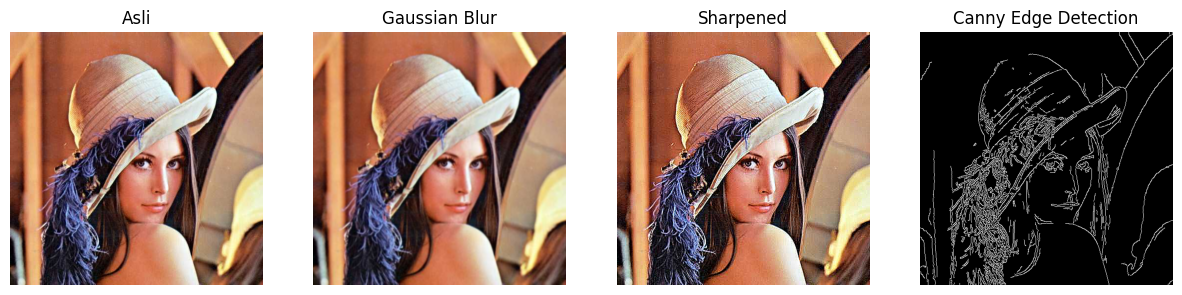

In [9]:
# Fungsi untuk menampilkan beberapa gambar secara berdampingan
def show_side_by_side(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2: # Jika gambar grayscale
            plt.subplot(1, len(images), i+1)
            plt.imshow(img, cmap="gray")
        else: # Jika gambar berwarna (RGB)
            plt.subplot(1, len(images), i+1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

# Load Image (Sesuaikan path letak gambar 'lena.jpg' di Google Drive Anda)
img = cv.imread("/content/drive/MyDrive/PCVK/Images/lena.jpg")
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# 1. Filter Gaussian Blur menggunakan library
blur = cv.GaussianBlur(img, (7,7), 1)

# 2. Canny Edge Detection menggunakan library (menerima input grayscale)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)

# 3. Filter Sharpen menggunakan fungsi filter2D bawaan OpenCV
sharpen_kernel = np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]])
# Menggunakan -1 agar kedalaman gambar output sama dengan gambar input
sharpened = cv.filter2D(img, -1, sharpen_kernel)

# Menampilkan hasil berdampingan
show_side_by_side([img, blur, sharpened, edges],
                  ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])

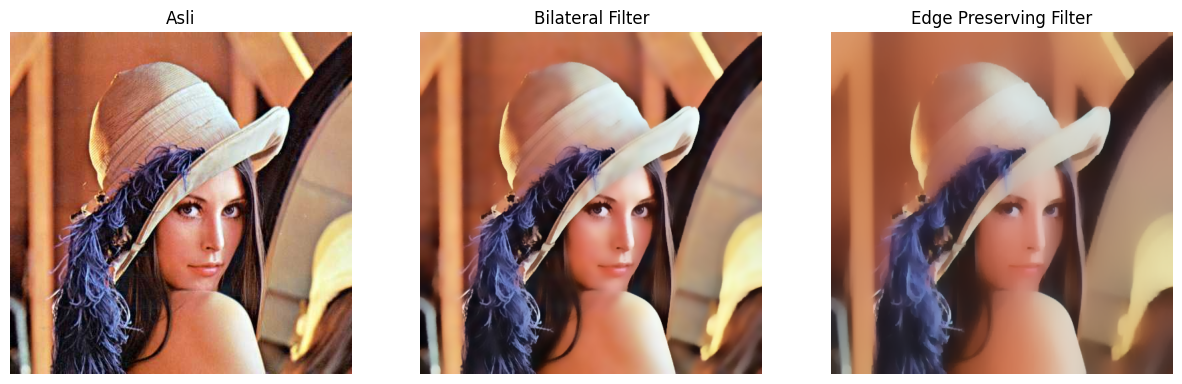

In [10]:
# 1. Bilateral Filter (edge-preserving)
bilateral = cv.bilateralFilter(img, 15, 100, 100)

# 2. Edge Preserving Filter (alternatif Guided Filter dari OpenCV)
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

# Menampilkan hasil secara berdampingan
show_side_by_side([img, bilateral, edge_preserve],
                  ["Asli", "Bilateral Filter", "Edge Preserving Filter"])

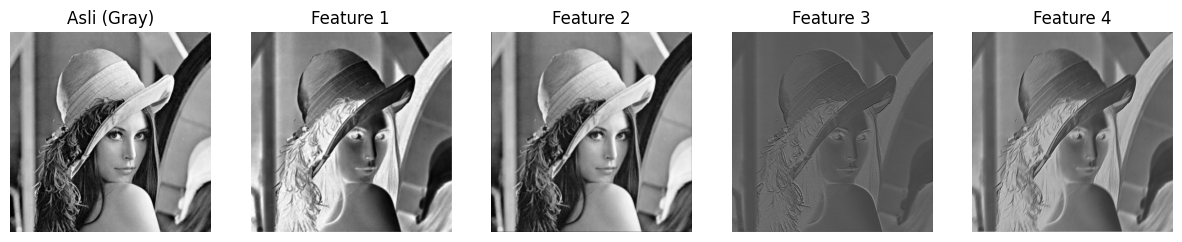

In [11]:
#Filter Feature Map yang digunakan pada CNN, Lakukan running code bagian ini beberapa kali dan perhatikan hasilnya
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

model = SimpleCNN()

# Ubah gambar ke tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# Hasil CNN
with torch.no_grad():
    features = model(img_tensor)

# Visualisasi feature maps
feature_maps = [features[0,i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_maps, ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))])

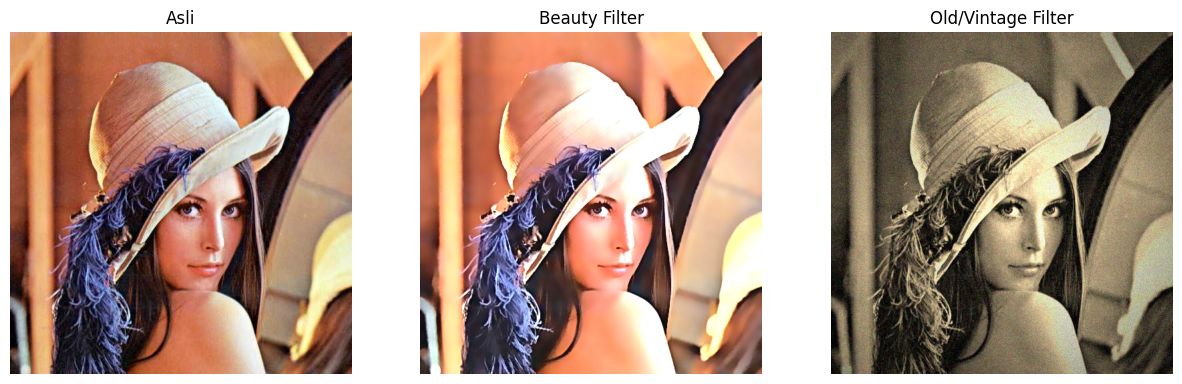

In [12]:
# 1. Beauty Filter
# =========================================================
# Step 1: Smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# Step 2: Unsharp masking (pertajam mata/bibir)
gaussian = cv.GaussianBlur(smooth, (0,0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

# Step 3: Brightness & contrast
alpha = 1.2 # contrast
beta = 15 # brightness
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)
# =========================================================


# 2. Old/Vintage Filter
# =========================================================
# Step 1: Sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# Step 2: Vignette
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(rows, rows*0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
    vignette[:,:,i] = vignette[:,:,i] * mask

# Step 3: Noise/Grain
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

# Menampilkan hasil Percobaan 4
show_side_by_side([img, beauty, old_img], ["Asli", "Beauty Filter", "Old/Vintage Filter"])

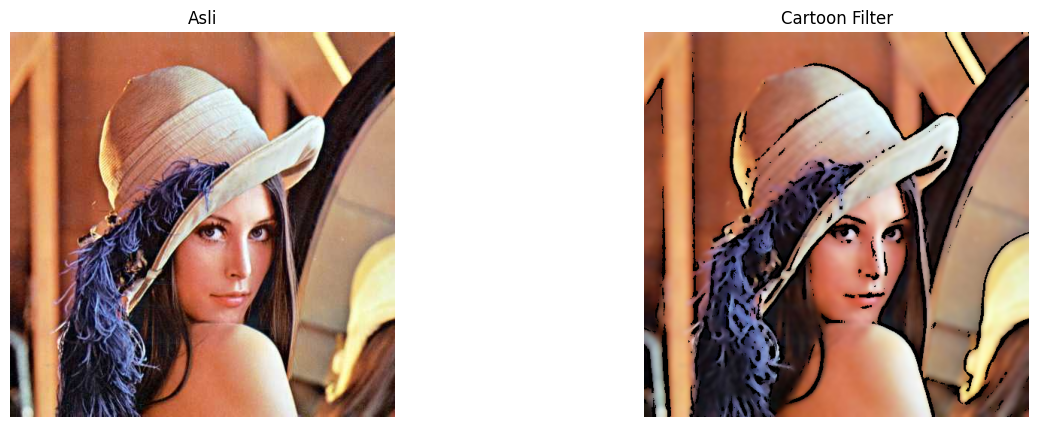

In [13]:
# Filter Anime / Cartoon
# Step 1: Edge detection (pakai median blur dulu agar gambar menjadi lebih halus)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, 9, 9)

# Step 2: Bilateral Filter untuk smoothing warna
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

# Step 3: Gabungkan (cartoonize)
cartoon = cv.bitwise_and(color, color, mask=edges)

show_side_by_side([img, cartoon], ["Asli", "Cartoon Filter"])

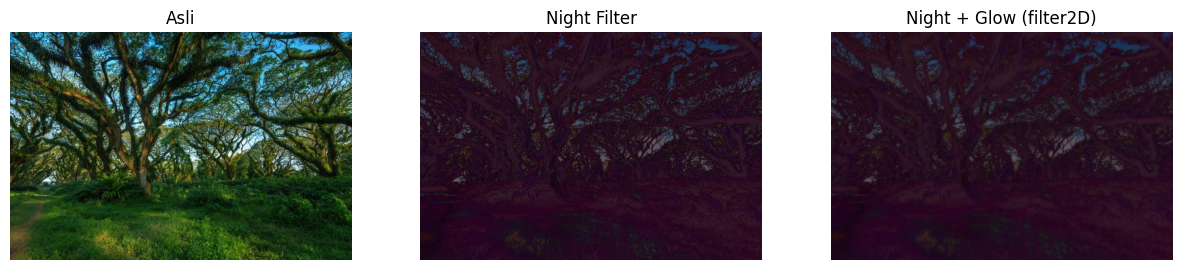

In [14]:
# Night Filter
img = cv.imread("/content/drive/MyDrive/PCVK/Images/djawatan.jpg")
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Step 1: Gelapkan (contrast turun, brightness negatif)
night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)

# Step 2: Tambah bias biru
blue_tint = np.full_like(night, (50, 0, 100)) # BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Step 3: Efek glow di area terang dengan filter2D (blur kernel)
kernel = np.ones((15,15), np.float32)/225
glow = cv.filter2D(night, -1, kernel)

# Kombinasikan asli + glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([img, night, night_glow], ["Asli", "Night Filter", "Night + Glow (filter2D)"])

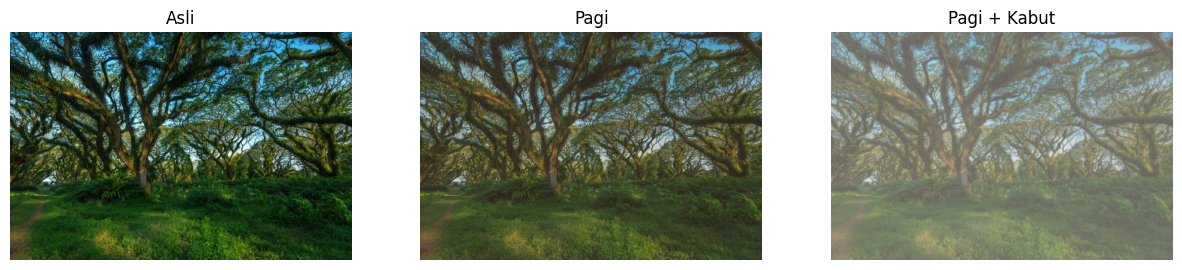

In [15]:
#Filter Suasana pagi dan Kabut
# =========================================================
# Step 1: Kurangi kontras & cerahkan
# =========================================================
alpha = 0.9 # contrast
# =========================================================
beta = 20 # brightness
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

# =========================================================
# Step 2: Tambahkan warm tone (kemerahan / oranye)
# =========================================================
warm_tint = np.full_like(soft, (40, 70, 120)) # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# =========================================================
# Step 3: Tambahkan haze (kabut tipis) dengan filter2D
# =========================================================
# Kernel blur Gaussian-Like untuk menciptakan efek kabut
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T # jadikan 2D kernel
kabut = cv.filter2D(pagi, -1, kernel)
# tambah layer putih untuk kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img, pagi, kabut],
                  ["Asli", "Pagi", "Pagi + Kabut"])